In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/isabelleeengel/qss-20-final-project/b02bb02c4d5e31413248b14cde567e741d819e36/data/CDC%20Wonder%20maternal%20death%20rates')
df.head()

,Notes,State,State Code,Single Race 6,Single Race 6 Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
0,NaN,Alabama,1.0,Black or African American,2054-5,65.0,9384181.0,0.7,0.5,0.9
1,NaN,Alabama,1.0,White,2106-3,60.0,24197348.0,0.2,0.2,0.3
2,NaN,Alaska,2.0,White,2106-3,10.0,3318369.0,0.3,0.1,0.6
3,NaN,Arizona,4.0,American Indian or Alaska Native,1002-5,18.0,2694672.0,0.7,0.4,1.1
4,NaN,Arizona,4.0,Black or African American,2054-5,18.0,2805255.0,0.6,0.4,1.0


In [3]:
print(df.columns.tolist())
print(df.shape)

['Notes', 'State', 'State Code', 'Single Race 6', 'Single Race 6 Code', 'Deaths', 'Population', 'Crude Rate', 'Crude Rate Lower 95% Confidence Interval', 'Crude Rate Upper 95% Confidence Interval']
(174, 10)


In [4]:
df_clean = df.drop(columns=['Notes'])
df_clean.columns = ['state', 'state_code', 'race', 'race_code', 'deaths', 'population', 'crude_rate', 'ci_lower', 'ci_upper']
df_clean.head()

,state,state_code,race,race_code,deaths,population,crude_rate,ci_lower,ci_upper
0,Alabama,1.0,Black or African American,2054-5,65.0,9384181.0,0.7,0.5,0.9
1,Alabama,1.0,White,2106-3,60.0,24197348.0,0.2,0.2,0.3
2,Alaska,2.0,White,2106-3,10.0,3318369.0,0.3,0.1,0.6
3,Arizona,4.0,American Indian or Alaska Native,1002-5,18.0,2694672.0,0.7,0.4,1.1
4,Arizona,4.0,Black or African American,2054-5,18.0,2805255.0,0.6,0.4,1.0


In [5]:
print(f"Rows: {len(df_clean)}")
print(f"States represented: {df_clean['state'].nunique()} out of 50 possible")
print(f"Races represented: {df_clean['race'].unique()}")

Rows: 174
States represented: 47 out of 50 possible
Races represented: ['Black or African American' 'White' 'American Indian or Alaska Native'
 'Asian' 'More than one race' nan]


In [6]:
df_clean[df_clean['race'].isna()]

,state,state_code,race,race_code,deaths,population,crude_rate,ci_lower,ci_upper
86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_clean = df_clean.dropna(subset=['state'])
print(f"Rows after cleanup: {len(df_clean)}")
print(f"Races represented: {df_clean['race'].unique()}")

Rows after cleanup: 86
Races represented: ['Black or African American' 'White' 'American Indian or Alaska Native'
 'Asian' 'More than one race']


In [8]:
df_clean.to_csv('cleaned_maternal_deaths.csv', index=False)

In [9]:
import matplotlib.pyplot as plt

agg = df_clean.groupby('race').agg(
    total_deaths=('deaths', 'sum'),
    total_population=('population', 'sum')
).reset_index()
agg['rate_per_100k'] = agg['total_deaths'] / agg['total_population'] * 100000
agg = agg.sort_values('rate_per_100k', ascending=False)
agg

,race,total_deaths,total_population,rate_per_100k
2,Black or African American,1817.0,3.059469e+08,0.593894
0,American Indian or Alaska Native,30.0,5.362319e+06,0.559459
4,White,3286.0,1.741302e+09,0.188709
3,More than one race,18.0,1.150526e+07,0.156450
1,Asian,117.0,7.872792e+07,0.148613


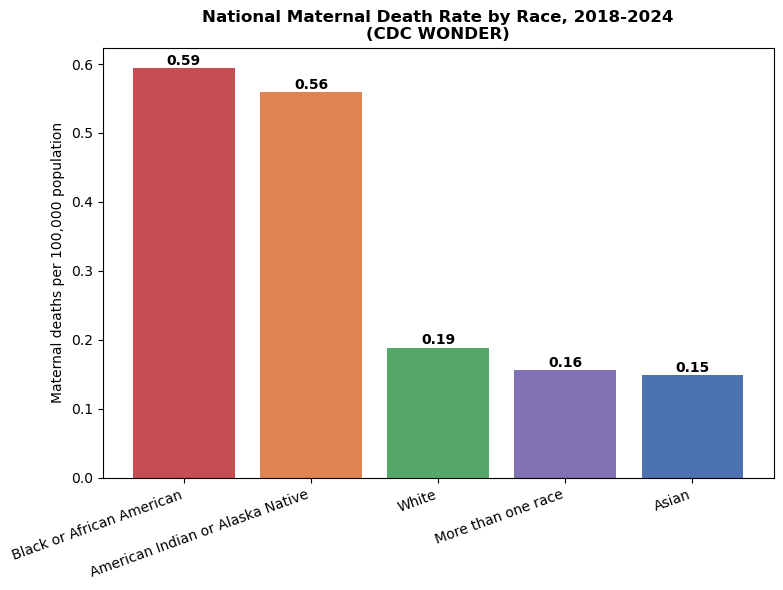

In [10]:
colors_map = {
    'Black or African American': '#C44E52',
    'American Indian or Alaska Native': '#DD8452',
    'White': '#55A868',
    'More than one race': '#8172B2',
    'Asian': '#4C72B0'
}

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(agg['race'], agg['rate_per_100k'], color=[colors_map.get(r,'#888') for r in agg['race']])

for bar, val in zip(bars, agg['rate_per_100k']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Maternal deaths per 100,000 population')
ax.set_title('National Maternal Death Rate by Race, 2018-2024\n(CDC WONDER)', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('national_rate_by_race.png', dpi=150)
plt.show()